# Regression on housing data

### Ques : 

Use the scikit learn library to implement linear regression for the House prediction dataset.

Report the following:

1. MSE obtained using Normal equations and Scikit learn (learning based) implementation
2. Report the parameters of the model based on Scikit learn and Normal equations
3. Observations.

Note- To make a fair evolution- use all the data for the training.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## EDA

In [53]:
housing = pd.read_csv("Housepriceprediction.csv")
housing.head()

,Id,LotArea,OverallQual,1stFlrSF,GrLivArea,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice
0,1,8450,7,856,1710,8,2,548,208500
1,2,9600,6,1262,1262,6,2,460,181500
2,3,11250,7,920,1786,6,2,608,223500
3,4,9550,7,961,1717,7,3,642,140000
4,5,14260,8,1145,2198,9,3,836,250000


In [54]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            1460 non-null   int64
 1   LotArea       1460 non-null   int64
 2   OverallQual   1460 non-null   int64
 3   1stFlrSF      1460 non-null   int64
 4   GrLivArea     1460 non-null   int64
 5   TotRmsAbvGrd  1460 non-null   int64
 6   GarageCars    1460 non-null   int64
 7   GarageArea    1460 non-null   int64
 8   SalePrice     1460 non-null   int64
dtypes: int64(9)
memory usage: 102.8 KB


In [55]:
housing.describe()

,Id,LotArea,OverallQual,1stFlrSF,GrLivArea,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,10516.828082,6.099315,1162.626712,1515.463699,6.517808,1.767123,472.980137,180921.195890
std,421.610009,9981.264932,1.382997,386.587738,525.480383,1.625393,0.747315,213.804841,79442.502883
min,1.000000,1300.000000,1.000000,334.000000,334.000000,2.000000,0.000000,0.000000,34900.000000
25%,365.750000,7553.500000,5.000000,882.000000,1129.500000,5.000000,1.000000,334.500000,129975.000000
50%,730.500000,9478.500000,6.000000,1087.000000,1464.000000,6.000000,2.000000,480.000000,163000.000000
75%,1095.250000,11601.500000,7.000000,1391.250000,1776.750000,7.000000,2.000000,576.000000,214000.000000
max,1460.000000,215245.000000,10.000000,4692.000000,5642.000000,14.000000,4.000000,1418.000000,755000.000000


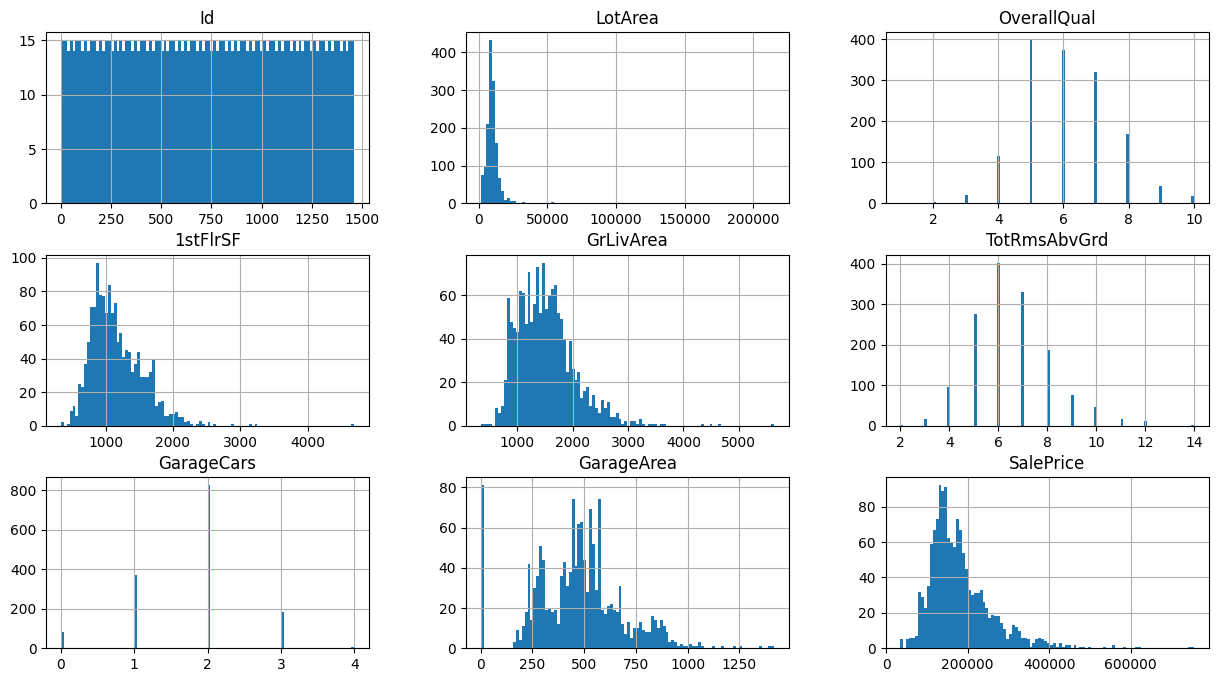

In [56]:
housing.hist(bins=100, figsize=(15,8))
plt.show()

## Regression Fit 

### Not doing a test-train split as requested

1.  All columns contain numerical data, which can be used. 
2.  Before fitting, we need to remove the index column

In [57]:
x = housing.drop(["Id", "SalePrice"], axis=1)
y = housing["SalePrice"]

print(x[:2])
print(y[:2])
print("Input shape:", x.shape)
print("Output shape:", y.shape)

   LotArea  OverallQual  1stFlrSF  GrLivArea  TotRmsAbvGrd  GarageCars  \
0     8450            7       856       1710             8           2   
1     9600            6      1262       1262             6           2   

   GarageArea  
0         548  
1         460  
0    208500
1    181500
Name: SalePrice, dtype: int64
Input shape: (1460, 7)
Output shape: (1460,)


## Linear Regression using Sklearn

In [58]:
X = x
Y = y

In [59]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_1 = LinearRegression()
model_1.fit(X, Y)

y_pred_1 =  model_1.predict(X)

mse_1 = mean_squared_error(Y, y_pred_1)

print(f"SK MSE: {mse_1}")
print(f"SK intercept : {model_1.intercept_}")
print(f"SK coff {model_1.coef_}" )


SK MSE: 1499498524.2084763
SK intercept : -107805.45590064817
SK coff [ 6.17664983e-01  2.64238353e+04  2.82589672e+01  4.12356858e+01
 -1.09884207e+03  1.36122815e+04  1.86585542e+01]


## Too large error. Dropping all the columns except the area of the house to predict the price

In [60]:

X = housing[['LotArea']]
Y = housing['SalePrice']

print("Feature shape:", X.shape)
print("Target shape:", Y.shape)

Feature shape: (1460, 1)
Target shape: (1460,)


In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_2 = LinearRegression()
model_2.fit(X, Y)

y_pred_2 =  model_2.predict(X)

mse_2 = mean_squared_error(Y, y_pred_2)

print(f"SK MSE: {mse_2}")
print(f"SK intercept : {model_2.intercept_}")
print(f"SK coff {model_2.coef_}" )


SK MSE: 5867752122.509074
SK intercept : 158836.1518968766
SK coff [2.09997195]


## Regression using Normal Equation and price column

In [62]:
x = housing[['LotArea']]
y = housing['SalePrice']

x = x.to_numpy()
y = y.to_numpy()

x = x.reshape(-1,1)
y = y.reshape(-1,1)

x = np.c_[np.ones(len(x)).reshape(-1,1), x]
print(x[:2])
print(y[:2])

[[1.00e+00 8.45e+03]
 [1.00e+00 9.60e+03]]
[[208500]
 [181500]]


In [64]:
X = x
Y = y

theta = np.linalg.inv(X.T @ X) @ (X.T @ Y)

print(np.round(theta,3))

[[1.58836152e+05]
 [2.10000000e+00]]


In [65]:
predictions = X @ theta


mse = np.mean((Y - predictions) ** 2)

print("MSE using Normal Equation:", mse)

MSE using Normal Equation: 5867752122.509075


In [66]:
print(f"MSE using SK: {mse_2}")
print(f"MSE using Normal equation: {mse}")

MSE using SK: 5867752122.509074
MSE using Normal equation: 5867752122.509075
